In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [13]:
df = pd.read_csv("../churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [17]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [18]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [19]:
df.dropna(inplace=True)

In [22]:
df.drop('customerID', axis=1, inplace=True)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

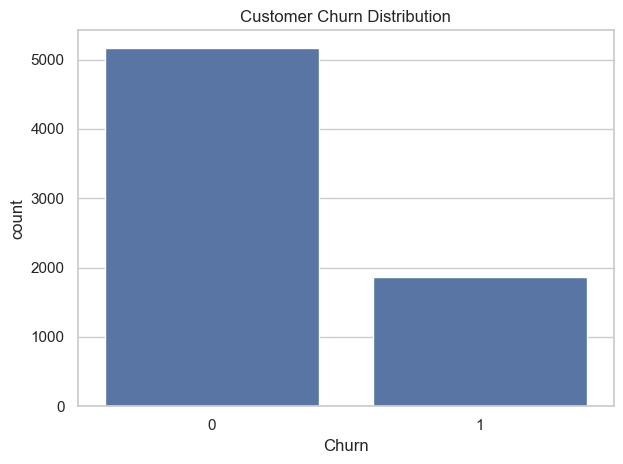

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure()
sns.countplot(x='Churn',data=df)
plt.title("Customer Churn Distribution")
plt.tight_layout()
plt.savefig("../images/churn_distribution.png")
plt.show()

In [25]:
(df['Churn'].value_counts(normalize=True) *100)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

## <span style="color:#2E86C1;">Churn Distribution Insight</span>

- <span style="color:#E74C3C;">27–26% customers have churned.</span>  
- <span style="color:#27AE60;">Around 73% customers are retained.</span>  

<span style="color:#F39C12;">
This indicates a significant churn rate, meaning the company is losing roughly 1 out of every 4 customers.
</span>


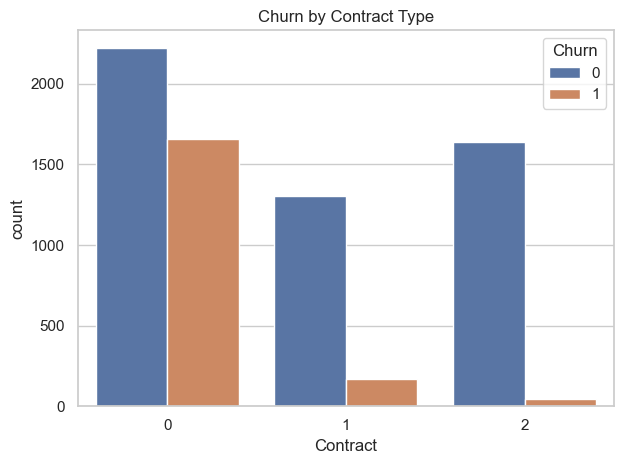

In [45]:
plt.figure()
sns.countplot(x='Contract',hue = 'Churn',data=df)
plt.title("Churn by Contract Type")
plt.tight_layout()
plt.savefig("../images/contract_churn.png")
plt.show()

## <span style="color:#2E86C1;">Contract vs Churn Insight</span>

- <span style="color:#E74C3C;">Customers with month-to-month contracts have the highest churn rate.</span>  
- <span style="color:#27AE60;">Customers with one-year and two-year contracts show significantly lower churn.</span>  
- <span style="color:#F39C12;">This suggests that longer contract commitments improve customer retention.</span>  

### <span style="color:#8E44AD;">Business Insight</span>

- <span style="color:#E74C3C;">Customers without long-term commitment are more likely to leave.</span>  
- <span style="color:#27AE60;">Encouraging long-term contracts can reduce churn.</span>  

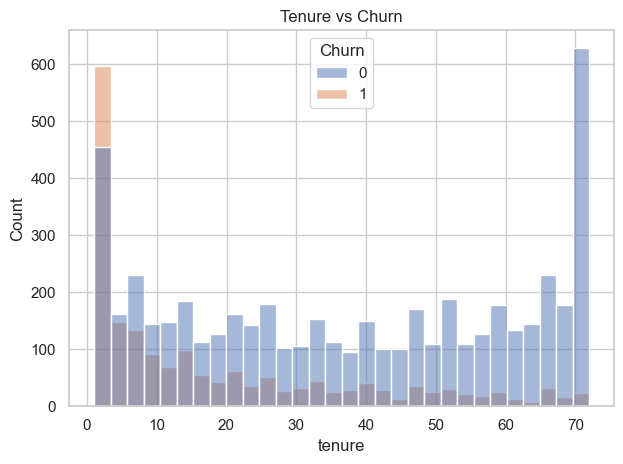

In [46]:
plt.figure()
sns.histplot(data=df,x='tenure',hue='Churn',bins=30)
plt.title("Tenure vs Churn")
plt.tight_layout()
plt.savefig("../images/tenure_churn.png")
plt.show()

## <span style="color:#2E86C1;">Tenure vs Churn Insight</span>

- <span style="color:#E74C3C;">Customers with very low tenure (0–10 months) show the highest churn.</span>  
- <span style="color:#F39C12;">Churn rate decreases significantly as tenure increases.</span>  
- <span style="color:#27AE60;">Long-term customers (50+ months) are much more likely to stay.</span>  

### <span style="color:#8E44AD;">Business Insight</span>

- <span style="color:#E74C3C;">The initial months of a customer’s journey are the most critical.</span>  
- <span style="color:#E67E22;">Poor onboarding or early dissatisfaction leads to higher churn.</span>  
- <span style="color:#27AE60;">Retention strategies should focus on the first 3–6 months.</span>  

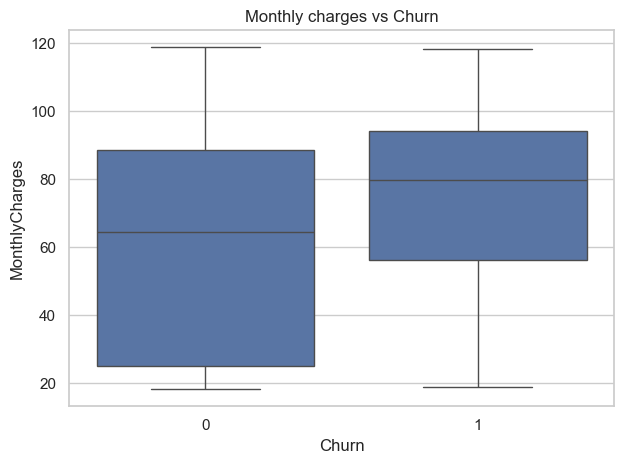

In [47]:
plt.figure()
sns.boxplot(x='Churn', y='MonthlyCharges',data=df)
plt.title("Monthly charges vs Churn")
plt.tight_layout()
plt.savefig("../images/charges_churn.png")
plt.show()

## <span style="color:#2E86C1;">Monthly Charges vs Churn Insight</span>

- <span style="color:#E74C3C;">Customers who churn tend to have higher monthly charges compared to those who stay.</span>  
- <span style="color:#F39C12;">The median monthly charge for churned customers is significantly higher.</span>  

### <span style="color:#8E44AD;">Business Insight</span>

- <span style="color:#E74C3C;">Higher pricing is a key factor contributing to customer churn.</span>  
- <span style="color:#E67E22;">Customers may perceive the service as expensive or not providing enough value.</span>  
- <span style="color:#27AE60;">Offering better pricing plans, discounts, or value-added services could help reduce churn.</span>  

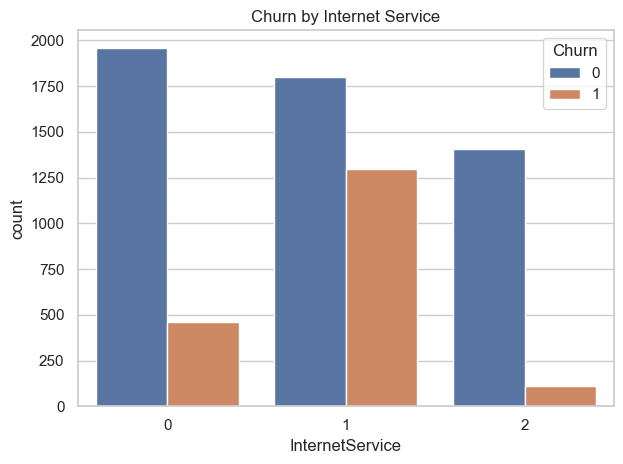

In [48]:
plt.figure()
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Churn by Internet Service")
plt.tight_layout()
plt.savefig("../images/internet_churn.png")
plt.show()

## <span style="color:#2E86C1;">Internet Service vs Churn Insight</span>

- <span style="color:#E74C3C;">Customers using fiber optic internet show significantly higher churn compared to DSL users.</span>  
- <span style="color:#27AE60;">Customers with no internet service have the lowest churn rate.</span>  

### <span style="color:#8E44AD;">Business Insight</span>

- <span style="color:#E74C3C;">Fiber optic users may be facing issues related to pricing, service quality, or expectations.</span>  
- <span style="color:#E67E22;">This segment requires immediate attention to reduce churn.</span>  
- <span style="color:#27AE60;">Improving service quality or offering better pricing plans for fiber users could help retain customers.</span>  

In [30]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [31]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [32]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [35]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [36]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7853589196872779
Confusion Matrix:
 [[920 113]
 [189 185]]


## <span style="color:#2E86C1;">Model Performance Analysis</span>

- <span style="color:#27AE60;">The model achieved an accuracy of ~78.5%.</span>  
- <span style="color:#27AE60;">It performs well in predicting non-churn customers.</span>  
- <span style="color:#E74C3C;">However, it struggles to correctly identify churned customers.</span>  

### <span style="color:#F39C12;">Key Insight</span>

- <span style="color:#E67E22;">The dataset is imbalanced, leading to better performance for majority class (non-churn).</span>  

### <span style="color:#8E44AD;">Business Impact</span>

- <span style="color:#E74C3C;">Missing churn customers is costly because these are the customers the company wants to retain.</span>  
- <span style="color:#27AE60;">Improving recall for churn class is important.</span>  

In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407

